In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/Superstore.csv", encoding="latin-1")
print(df.shape)
df.head()

(9994, 21)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [2]:
df["Order Date"] = pd.to_datetime(df["Order Date"], errors="coerce")
print("Date range:", df["Order Date"].min(), "→", df["Order Date"].max())
print("Unparsed dates:", df["Order Date"].isna().sum())

Date range: 2014-01-03 00:00:00 → 2017-12-30 00:00:00
Unparsed dates: 0


In [3]:
ts = df.set_index("Order Date")["Sales"].resample("MS").sum()
ts.head()

Order Date
2014-01-01    14236.895
2014-02-01     4519.892
2014-03-01    55691.009
2014-04-01    28295.345
2014-05-01    23648.287
Freq: MS, Name: Sales, dtype: float64

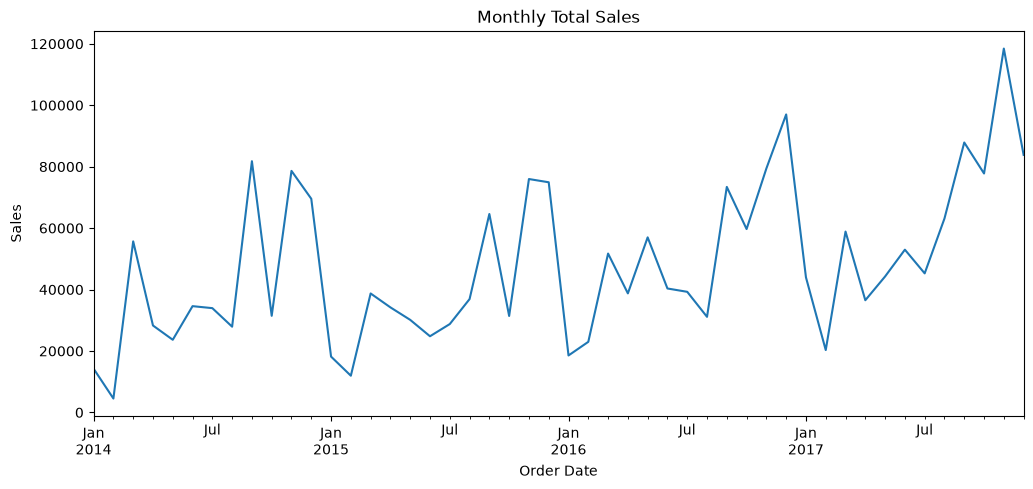

In [4]:
plt.figure(figsize=(12,5))
ts.plot()
plt.title("Monthly Total Sales")
plt.ylabel("Sales")
plt.show()

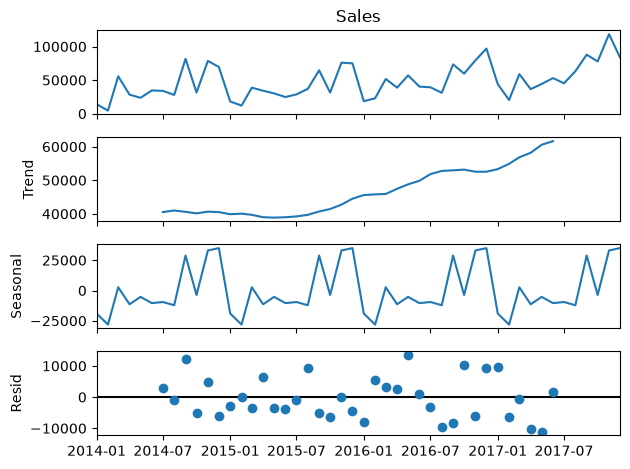

In [5]:
from statsmodels.tsa.seasonal import seasonal_decompose

result = seasonal_decompose(ts, model="additive", period=12)
result.plot()
plt.show()

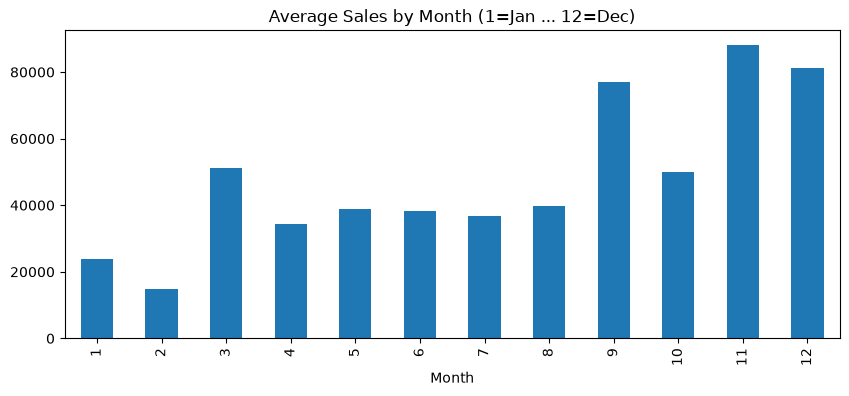

In [6]:
monthly_avg = ts.groupby(ts.index.month).mean()
plt.figure(figsize=(10,4))
monthly_avg.plot(kind="bar")
plt.title("Average Sales by Month (1=Jan ... 12=Dec)")
plt.xlabel("Month")
plt.show()